### Pre-requisites


In [61]:
# import needed python libraries

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import random
import statistics
import functions as fnc


## Dataset

we start by importing the pre-processed dataframes generated in section 1 

In [62]:
df_domC = pd.read_pickle('df_domC.pkl')

Working with a data set with more features was not helpful.

# Section 3

We analyse by domain knowledge what the websites are providing. Hopefuly we could cluster these together. There are 4 labels bellow
These labels will be used for Adjusted rand-index, to numerically evaluate if the cluesters are groupping flows of the same category

| Domain                | Primary Label              | Notes / Supporting Function                                             |
| :-------------------- | :------------------------- | :---------------------------------------------------------------------- |
| adnxs.com             | **Ad Tech / Analytics**    | Advertising exchange (AppNexus); short, frequent tracking/auction flows |
| ads-twitter.com       | **Ad Tech / Analytics**    | Twitter/X advertising delivery and tracking                             |
| chartbeat.com         | **Ad Tech / Analytics**    | Real-time analytics and audience measurement                            |
| contextweb.com        | **Ad Tech / Analytics**    | Contextual advertising and real-time bidding                            |
| disqus.com            | **Social & Community**     | Embedded comment system for websites                                    |
| everesttech.net       | **Ad Tech / Analytics**    | Adobe advertising, tracking, and attribution services                   |
| fastly-insights.com   | **Telemetry & Monitoring** | CDN performance and monitoring telemetry                                |
| fastly.net            | **Infrastructure & CDN**   | Major global content delivery network                                   |
| ftcdn.net             | **Infrastructure & CDN**   | CDN for *Financial Times* media assets                                  |
| giphy.com             | **Media Service**          | GIF search and delivery platform                                        |
| githubusercontent.com | **Static Content Hosting** | Hosting of static assets and raw files                                  |
| krxd.net              | **Ad Tech / Analytics**    | Advertising data management and user tracking                           |
| newrelic.com          | **Telemetry & Monitoring** | Application and infrastructure performance monitoring                   |
| outbrain.com          | **Ad Tech / Analytics**    | Content recommendation and native advertising                           |
| pinterest.com         | **Social & Community**     | Visual discovery and bookmarking platform                               |
| polyfill.io           | **Static Content Hosting** | Delivery of JavaScript polyfills                                        |
| redd.it               | **Social & Community**     | Reddit URL shortener and redirect service                               |
| reddit.com            | **Social & Community**     | Social news aggregation and discussion forum                            |
| scdn.co               | **Media Service**          | SoundCloud CDN for audio streaming                                      |
| slack-edge.com        | **Infrastructure & CDN**   | Slack asset and file delivery via CDN                                   |
| taboola.com           | **Ad Tech / Analytics**    | Content recommendation and advertising                                  |
| twimg.com             | **Infrastructure & CDN**   | Twitter/X image and media CDN                                           |
| twitch.tv             | **Media Service**          | Live video streaming platform                                           |
| twitchcdn.net         | **Media Service**          | Dedicated CDN for Twitch video delivery                                 |
| vimeocdn.com          | **Media Service**          | Video delivery CDN for Vimeo                                            |


In [69]:
import pandas as pd

# Create a dictionary with domain as key and primary label as value
domain_labels = {
    "adnxs.com": "Ad Tech / Analytics",
    "ads-twitter.com": "Ad Tech / Analytics",
    "chartbeat.com": "Ad Tech / Analytics",
    "contextweb.com": "Ad Tech / Analytics",
    "disqus.com": "Social & Community",
    "everesttech.net": "Ad Tech / Analytics",
    "fastly-insights.com": "Ad Tech / Analytics",
    "fastly.net": "Infrastructure & CDN",
    "ftcdn.net": "Infrastructure & CDN",
    "giphy.com": "Media Service",
    "githubusercontent.com": "Static Content Hosting",
    "krxd.net": "Ad Tech / Analytics",
    "newrelic.com": "Ad Tech / Analytics",
    "outbrain.com": "Ad Tech / Analytics",
    "pinterest.com": "Social & Community",
    "polyfill.io": "Static Content Hosting",
    "redd.it": "Social & Community",
    "reddit.com": "Social & Community",
    "scdn.co": "Media Service",
    "slack-edge.com": "Infrastructure & CDN",
    "taboola.com": "Ad Tech / Analytics",
    "twimg.com": "Infrastructure & CDN",
    "twitch.tv": "Media Service",
    "twitchcdn.net": "Media Service",
    "vimeocdn.com": "Media Service",
    "_other": "other"
}



# Create DataFrame with domains as index and labels as a column
df_labels = pd.DataFrame.from_dict(domain_labels, orient='index', columns=['Primary_Label'])

# Display the DataFrame
print("DataFrame with domains as index and primary labels:")
print("=" * 60)
print(df_labels)
print("\n" + "=" * 60)
print(f"Total domains: {len(df_labels)}")
print(f"Label distribution:")
print(df_labels['Primary_Label'].value_counts())

# Optional: Add a numeric encoding for the labels if needed for ML
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_labels['Label_Encoded'] = encoder.fit_transform(df_labels['Primary_Label'])



DataFrame with domains as index and primary labels:
                                Primary_Label
adnxs.com                 Ad Tech / Analytics
ads-twitter.com           Ad Tech / Analytics
chartbeat.com             Ad Tech / Analytics
contextweb.com            Ad Tech / Analytics
disqus.com                 Social & Community
everesttech.net           Ad Tech / Analytics
fastly-insights.com       Ad Tech / Analytics
fastly.net               Infrastructure & CDN
ftcdn.net                Infrastructure & CDN
giphy.com                       Media Service
githubusercontent.com  Static Content Hosting
krxd.net                  Ad Tech / Analytics
newrelic.com              Ad Tech / Analytics
outbrain.com              Ad Tech / Analytics
pinterest.com              Social & Community
polyfill.io            Static Content Hosting
redd.it                    Social & Community
reddit.com                 Social & Community
scdn.co                         Media Service
slack-edge.com           Inf

## 3.1

## K-means clustering

11 features removed


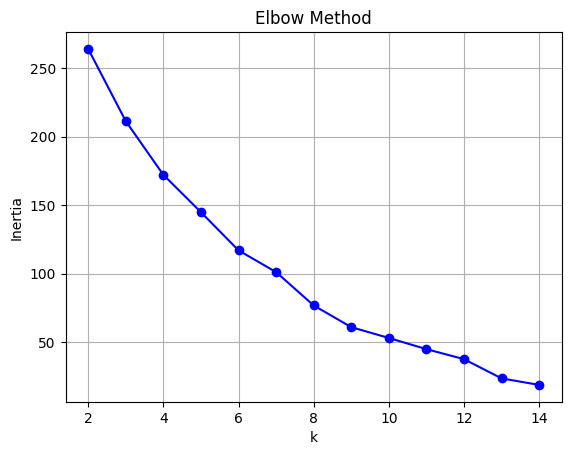

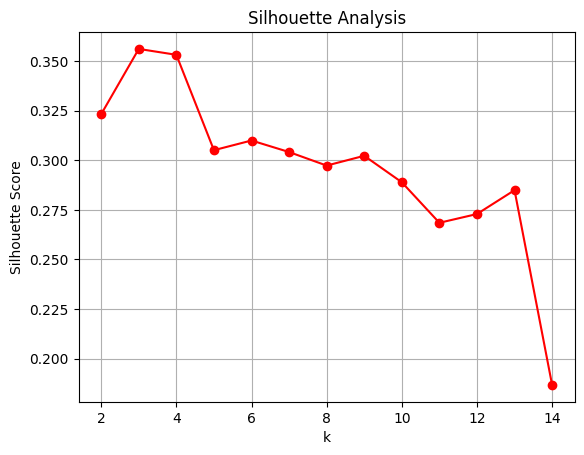

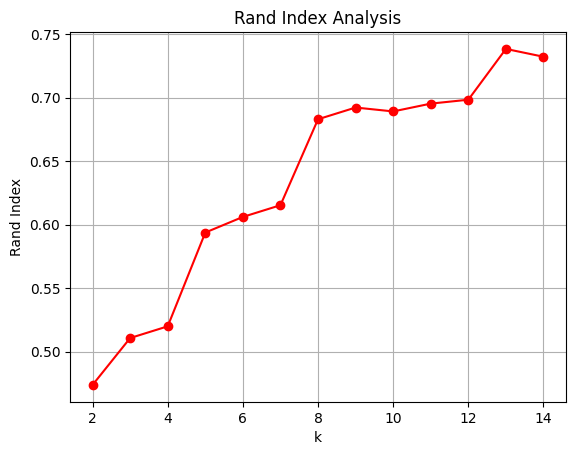

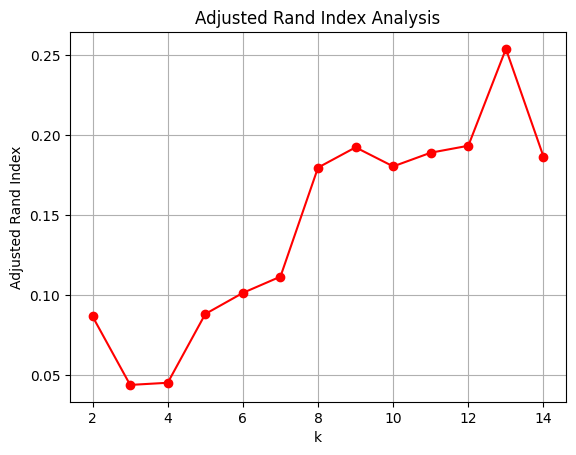

DOMAIN NAMES GROUPED BY CLUSTER

K = 2 CLUSTERS

Cluster 0 (6 domains):
------------------------------
   1. giphy.com Media Service
   2. redd.it Social & Community
   3. scdn.co Media Service
   4. slack-edge.com Infrastructure & CDN
   5. taboola.com Ad Tech / Analytics
   6. vimeocdn.com Media Service

Cluster 1 (20 domains):
------------------------------
   1. _other other
   2. adnxs.com Ad Tech / Analytics
   3. ads-twitter.com Ad Tech / Analytics
   4. chartbeat.com Ad Tech / Analytics
   5. contextweb.com Ad Tech / Analytics
   6. disqus.com Social & Community
   7. everesttech.net Ad Tech / Analytics
   8. fastly-insights.com Ad Tech / Analytics
   9. fastly.net Infrastructure & CDN
  10. ftcdn.net Infrastructure & CDN
  11. githubusercontent.com Static Content Hosting
  12. krxd.net Ad Tech / Analytics
  13. newrelic.com Ad Tech / Analytics
  14. outbrain.com Ad Tech / Analytics
  15. pinterest.com Social & Community
  16. polyfill.io Static Content Hosting
  17. reddit.com

In [70]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, rand_score

X_s, _ = fnc.remove_correlated_features(df_domC, df_domC, correlation_threshold=0.90)

#X_s,_  = remove_correlated_features(df_dom_d, df_dom_d, correlation_threshold=0.7)
#######Tried with PCA and it is just as bad ############
#actualy a lot worse in DBSCAN
#pca = PCA(12)
#X_s = pca.fit_transform(df_domC.dropna())
#plot_corrMat(pd.DataFrame(X_s).corr().abs())
########################################################

# Elbow method

random_state = 45
inertias = []
sil_scores = []
RI_scores = []
ARI_scores = []
K_range = range(2, 15)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=random_state)
    km.fit(X_s)
    inertias.append(km.inertia_)
    labels_km = km.predict(X_s)
    sil_scores.append(silhouette_score(X_s, labels_km))
    ARI_scores.append(adjusted_rand_score(df_labels['Label_Encoded'], labels_km))
    RI_scores.append(rand_score(df_labels['Label_Encoded'], labels_km))

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')   
plt.title('Elbow Method')
plt.grid()

plt.show()

plt.plot(K_range, sil_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()



plt.plot(K_range, RI_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Rand Index')
plt.title('Rand Index Analysis')
plt.show()

plt.plot(K_range, ARI_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Adjusted Rand Index')
plt.title('Adjusted Rand Index Analysis')
plt.show()



print("=" * 60)
print("DOMAIN NAMES GROUPED BY CLUSTER")
print("=" * 60)

for k in range(2, 14):
    km = KMeans(n_clusters=k, random_state=random_state)
    cluster_labels = km.fit_predict(X_s)
    
    # Create a DataFrame with domain names and their cluster assignments
    cluster_df = pd.DataFrame({
        'domain': df_domC.index,
        'cluster': cluster_labels
    })
    
    print(f"\n{'='*40}")
    print(f"K = {k} CLUSTERS")
    print(f"{'='*40}")
    
    # Group domains by cluster and print
    for cluster_id in range(k):
        domains_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['domain'].tolist()
        print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
        print("-" * 30)
        
        # Print domains in a readable format (wrap text if needed)
        for i, domain in enumerate(domains_in_cluster, 1):
            print(f"  {i:2d}. {domain}", domain_labels[domain])
    
    # Print some statistics
    cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
    print(f"\nCluster size distribution:")
    for cluster_id, size in cluster_sizes.items():
        print(f"  Cluster {cluster_id}: {size} domains")
    
    # Calculate silhouette score for this k
    sil_score = silhouette_score(X_s, cluster_labels)
    print(f"  Silhouette Score: {sil_score:.4f}")


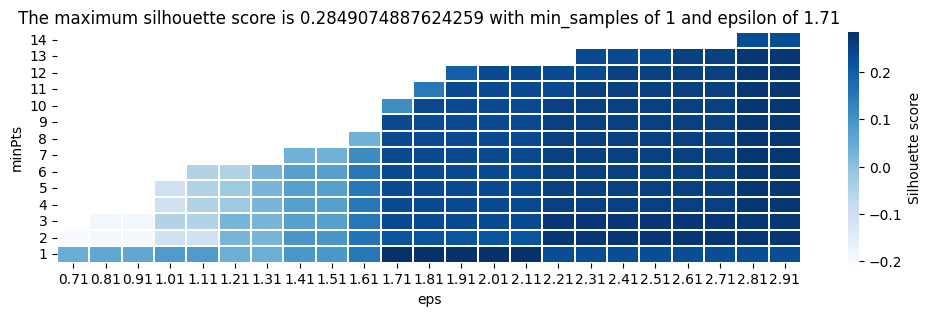

Number of clusters (including noise):  13
Size of each cluster:  [ 1 13  2  1  1  1  1  1  1  1  1  1  1]
Silhouette: 0.28
RI: 0.74
ARI: 0.25


In [107]:
from sklearn.cluster import DBSCAN

# Now analyze the performance varying epsilon and min_samples.

shs = []
for eps in np.arange(0.01, 3.0, 0.1):
    eps = round(eps,3)
    for mins in range(1, 20):
        dbscan = DBSCAN(eps=eps, min_samples=mins)
        cl_labels3 = dbscan.fit_predict(X_s)
        try:
            silhouette  = silhouette_score(X_s, cl_labels3)
        except:
            silhouette = np.nan
        shs.append((eps, mins, silhouette))

gs = pd.DataFrame(shs, columns=['eps', 'minPts', 'sh'])
gs = pd.pivot_table(gs, columns='eps', index='minPts', values='sh', aggfunc=lambda x:x)

# Plot the silhouette score for the different values with a heatmap

plt.figure(figsize=(12,3))
max_ss = gs.max().max()
mins_max_ss = gs.stack().idxmax()[0]
eps_max_ss = gs.stack().idxmax()[1]
plt.title(f'The maximum silhouette score is {max_ss} with min_samples of {mins_max_ss} and epsilon of {eps_max_ss}')
sns.heatmap(gs, cmap='Blues', cbar_kws={'label':'Silhouette score'}, linewidths=.005)
plt.gca().invert_yaxis()
plt.show()

# Report the results of the best combination, also on other metrics

dbscan = DBSCAN(eps=eps_max_ss, min_samples=mins_max_ss )
cl_labels = dbscan.fit_predict(X_s) # Get clusters ID

# Unsupervised metric
silhouette  = silhouette_score(X_s, cl_labels)
# Supervised metrics
ri = rand_score(df_labels['Label_Encoded'], cl_labels)
ari = adjusted_rand_score(df_labels['Label_Encoded'], cl_labels)

# report number and size of each cluster
(unique, counts)=np.unique( cl_labels, return_counts=True)
print("Number of clusters (including noise): ", len(unique))
print("Size of each cluster: ", counts)
# report usupervised and supervised metric
print(f'Silhouette: {round(silhouette, 2)}')
print(f'RI: {round(ri, 2)}')
print(f'ARI: {round(ari, 2)}')

In [112]:


cluster_labels = dbscan.fit_predict(X_s)

# Create a DataFrame with domain names and their cluster assignments
cluster_df = pd.DataFrame({
    'domain': df_domC.index,
    'cluster': cluster_labels
})

print(f"\n{'='*40}")
print(f"K = {k} CLUSTERS")
print(f"{'='*40}")

# Group domains by cluster and print
for cluster_id in range(k):
    domains_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['domain'].tolist()
    print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
    print("-" * 30)
    
    # Print domains in a readable format (wrap text if needed)
    for i, domain in enumerate(domains_in_cluster, 1):
        print(f"  {i:2d}. {domain}", domain_labels[domain])

# Print some statistics
cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
print(f"\nCluster size distribution:")
for cluster_id, size in cluster_sizes.items():
    print(f"  Cluster {cluster_id}: {size} domains")

# Calculate silhouette score for this k
sil_score = silhouette_score(X_s, cluster_labels)
print(f"  Silhouette Score: {sil_score:.4f}")


K = 13 CLUSTERS

Cluster 0 (1 domains):
------------------------------
   1. _other other

Cluster 1 (13 domains):
------------------------------
   1. adnxs.com Ad Tech / Analytics
   2. ads-twitter.com Ad Tech / Analytics
   3. chartbeat.com Ad Tech / Analytics
   4. contextweb.com Ad Tech / Analytics
   5. disqus.com Social & Community
   6. everesttech.net Ad Tech / Analytics
   7. fastly.net Infrastructure & CDN
   8. githubusercontent.com Static Content Hosting
   9. krxd.net Ad Tech / Analytics
  10. newrelic.com Ad Tech / Analytics
  11. outbrain.com Ad Tech / Analytics
  12. pinterest.com Social & Community
  13. polyfill.io Static Content Hosting

Cluster 2 (2 domains):
------------------------------
   1. fastly-insights.com Ad Tech / Analytics
   2. ftcdn.net Infrastructure & CDN

Cluster 3 (1 domains):
------------------------------
   1. giphy.com Media Service

Cluster 4 (1 domains):
------------------------------
   1. redd.it Social & Community

Cluster 5 (1 domains):

In [ ]:
from collections import defaultdict

# Build cluster → domains mapping
clusters = defaultdict(list)

for domain, category, cluster in zip(
    df_labels["Domain"],
    df_labels["Category"],
    cl_labels
):
    clusters[cluster].append((domain, category))

# Sort clusters (noise last)
sorted_clusters = sorted(
    clusters.items(),
    key=lambda x: (x[0] == -1, x[0])
)

# Count non-noise clusters
k_clusters = len([c for c in clusters.keys() if c != -1])

print("=" * 40)
print(f"K = {k_clusters} CLUSTERS")
print("=" * 40)
print()

# Print clusters
for cluster_id, items in sorted_clusters:
    cluster_name = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"
    
    print(f"{cluster_name} ({len(items)} domains):")
    print("-" * 30)
    
    for i, (domain, category) in enumerate(sorted(items), 1):
        print(f"{i:>4}. {domain} {category}")
    
    print()


In [108]:
pca = PCA(n_components=2)
projection = pca.fit_transform(X_s)
projection = pd.DataFrame(projection)


K = 13 CLUSTERS

Cluster 0 (1 domains):
------------------------------
   1. _other

Cluster 1 (13 domains):
------------------------------
   1. adnxs.com
   2. ads-twitter.com
   3. chartbeat.com
   4. contextweb.com
   5. disqus.com
   6. everesttech.net
   7. fastly.net
   8. githubusercontent.com
   9. krxd.net
  10. newrelic.com
  11. outbrain.com
  12. pinterest.com
  13. polyfill.io

Cluster 2 (2 domains):
------------------------------
   1. fastly-insights.com
   2. ftcdn.net

Cluster 3 (1 domains):
------------------------------
   1. giphy.com

Cluster 4 (1 domains):
------------------------------
   1. redd.it

Cluster 5 (1 domains):
------------------------------
   1. reddit.com

Cluster 6 (1 domains):
------------------------------
   1. scdn.co

Cluster 7 (1 domains):
------------------------------
   1. slack-edge.com

Cluster 8 (1 domains):
------------------------------
   1. taboola.com

Cluster 9 (1 domains):
------------------------------
   1. twimg.com

Cluste

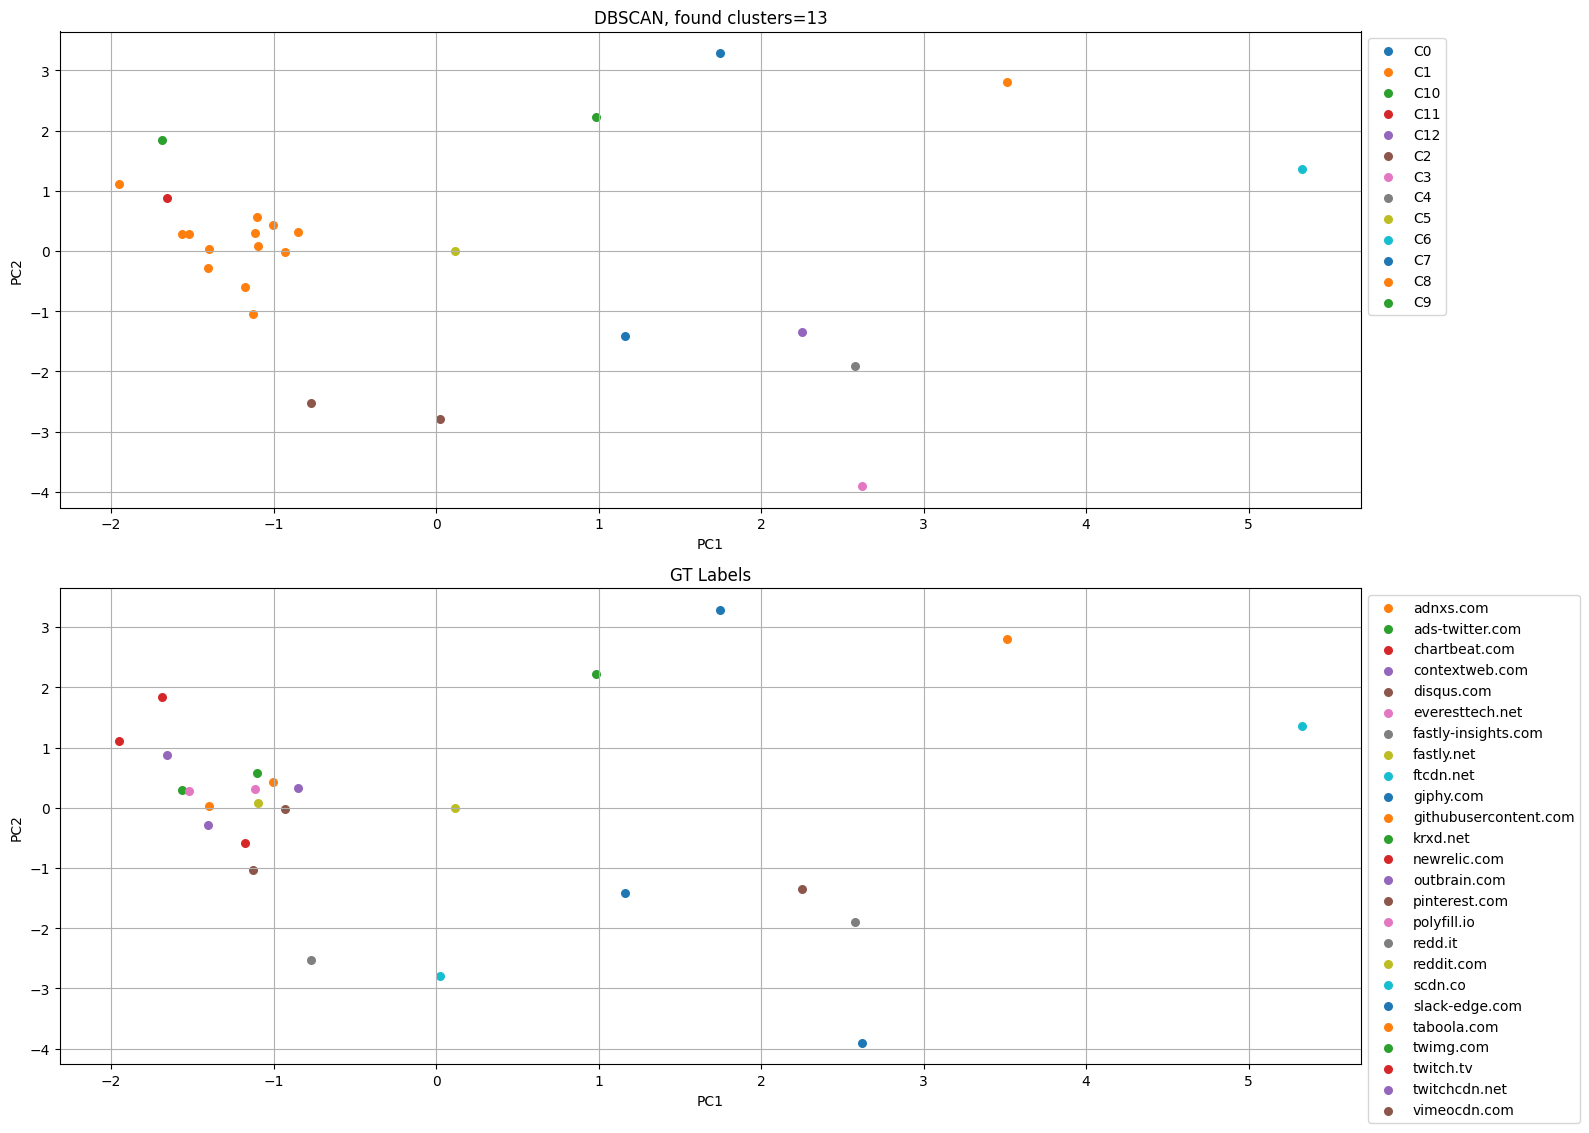

In [109]:
# reuse 2D PCA
# plots

projection['cidBest'] = [f'C{x}' for x in cl_labels]
projection['label'] = df_domC.index

fig, axs = plt.subplots(2, 1, figsize=(16, 12))

for i in np.unique(projection.cidBest):
    subdf = projection[projection.cidBest==i]
    axs[0].scatter(subdf[0], subdf[1], label=i, s=30)
axs[0].grid()
lgnd = axs[0].legend(bbox_to_anchor=(1, 1), loc="upper left")

axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title(f'DBSCAN, found clusters={len(unique)}')

for i in np.unique(df_domC.index):
    subdf = projection[projection.label==i]
    axs[1].scatter(subdf[0], subdf[1], label=i, s=30)
axs[1].grid()
lgnd = axs[1].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title('GT Labels')



# Create a DataFrame with domain names and their cluster assignments
cluster_df = pd.DataFrame({
    'domain': df_domC.index,
    'cluster': cl_labels
})

k = len(unique)
print(f"\n{'='*40}")
print(f"K = {len(unique)} CLUSTERS")
print(f"{'='*40}")

# Group domains by cluster and print
for cluster_id in range(k):
    domains_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['domain'].tolist()
    print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
    print("-" * 30)
    
    # Print domains in a readable format (wrap text if needed)
    for i, domain in enumerate(domains_in_cluster, 1):
        print(f"  {i:2d}. {domain}")

# Print some statistics
cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
print(f"\nCluster size distribution:")
for cluster_id, size in cluster_sizes.items():
    print(f"  Cluster {cluster_id}: {size} domains")

# Calculate silhouette score for this k
sil_score = silhouette_score(X_s, cluster_labels)
print(f"  Silhouette Score: {sil_score:.4f}")


plt.tight_layout()
plt.show()